In [1]:
# Import key libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Calculate the width of one letter in a matplotlib figure

In [6]:
fig,ax = plt.subplots(figsize=(10,2))

# draw a text object
temp_text = ax.text(x=0,y=0,s='n',fontsize=12,fontfamily='monospace')

# get its bounding box in display coordinates
bbox = temp_text.get_window_extent(renderer=fig.canvas.get_renderer())

# convert from display to axis coordinates
inv = ax.transAxes.inverted()
bbox_axes = inv.transform([[bbox.x0,bbox.y0], [bbox.x1,bbox.y1]])
en_width = bbox_axes[1,0] - bbox_axes[0,0] # bbox is [(x0,y0),(x1,y1)]

plt.close(fig)
en_width

np.float64(0.012903225806451618)

# Color words according to character count

In [8]:
# some text
text = 'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.'

# "tokenize" the text
words = text.split()

In [9]:
# get the lengths of the words and convert to numpy
lens = [len(i) for i in words]
lens = np.array(lens)

# min/max scale
charcountsScale = (lens-lens.min()) / (lens.max()-lens.min())

# Visualize the Heatmap

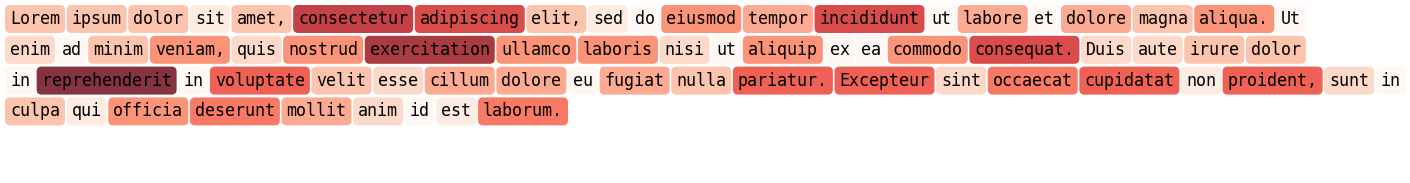

In [10]:
wordCount = 0

x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

fig, ax = plt.subplots(figsize=(10,2))
ax.axis('off')


for i,word in enumerate(words):

  # width of the word
  word_width = en_width*len(word)

  # "activation" is the length of the word
  activation = charcountsScale[i]

  # text object with background color matching the "activation"
  ax.text(x_pos+word_width/2, y_pos, word, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Reds(activation), edgecolor='none', alpha=.8))

  # update the word counter and x_pos
  wordCount += 1
  x_pos += word_width + .015 # plus a small gap

  # end of the line; reset coordinates and counter
  if wordCount>=20:
    y_pos -= .2
    x_pos = 0
    wordCount = 0

plt.show()